In [91]:
import os
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams["font.family"] = "Arial"
plt.rcParams["font.size"] = 12

In [92]:
workdir = os.getcwd()

FTAN_f77_datadir = os.path.join(workdir, "FTAN_f77", "FTAN")
FTAN_python_datadir = os.path.join(workdir, "FTAN_python", "FTAN")

FTAN_f77_file = os.path.join(FTAN_f77_datadir, "TA_M07A_TA_M15A.npz")
FTAN_python_file = os.path.join(FTAN_python_datadir, "TA_M07A_TA_M15A.npz") 


In [93]:
FTAN_f77_dat = np.load(FTAN_f77_file)
FTAN_python_dat = np.load(FTAN_python_file)
print(FTAN_f77_dat.files)
print(FTAN_f77_dat["pmf2"])
# print(FTAN_f77_dat["pct"])
# print(FTAN_f77_dat["dist"])
# print(FTAN_f77_dat["nsrc"])

['pmf2', 'pct', 'dist', 'nsrc']
[[  5.24321466   2.6582815    2.92781068  31.69564701]
 [  5.27525601   2.6595921    2.92965529  31.98539222]
 [  5.31022282   2.66117423   2.93166019  32.28912244]
 [  5.34835262   2.66307823   2.9338356   32.60340201]
 [  5.38996041   2.66536841   2.93619496  33.15249337]
 [  5.43547012   2.66812722   2.93875631  33.85238112]
 [  5.4858242    2.67134442   2.94156218  34.63377994]
 [  5.54175298   2.67512943   2.94464578  35.50859167]
 [  5.60399343   2.67971808   2.94803092  36.48835344]
 [  5.67414816   2.68507693   2.95178142  37.59751061]
 [  5.75373193   2.6913409    2.95595387  38.85804326]
 [  5.84416073   2.69858744   2.96058199  40.64727414]
 [  5.94671432   2.70680207   2.9656896   43.20333131]
 [  6.06069642   2.71563933   2.97119297  46.63555177]
 [  6.18521375   2.72501602   2.97700712  50.15010916]
 [  6.31780018   2.73444441   2.98298343  53.56127532]
 [  6.45350711   2.74331536   2.98889433  56.63544756]
 [  6.59432839   2.75150114   2.9

In [94]:
FTAN_seisforge_datadir = os.path.join(workdir, "FTAN_seisforge")
FTAN_seisforge_file = os.path.join(FTAN_seisforge_datadir, "COR_M07A_M15A.stack.pmf.dat")

FTAN_seisforge_dat = np.loadtxt(FTAN_seisforge_file, skiprows=1)

Text(0, 0.5, 'Phase Velocity (km/s)')

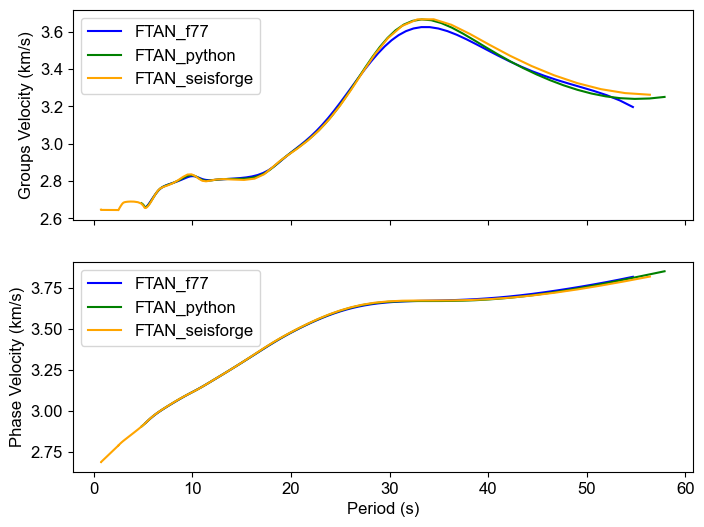

In [95]:
fig, ax = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

ax[0].plot(FTAN_f77_dat["pmf2"][:, 0], FTAN_f77_dat["pmf2"][:, 1], label="FTAN_f77", color="blue")
ax[0].plot(FTAN_python_dat["pmf2"][:, 0], FTAN_python_dat["pmf2"][:, 1], label="FTAN_python", color="green")
ax[0].plot(FTAN_seisforge_dat[:, 1], FTAN_seisforge_dat[:, 2], label="FTAN_seisforge", color="orange")
ax[0].legend()
ax[0].set_ylabel("Groups Velocity (km/s)")

ax[1].plot(FTAN_f77_dat["pmf2"][:, 0], FTAN_f77_dat["pmf2"][:, 2], label="FTAN_f77", color="blue")
ax[1].plot(FTAN_python_dat["pmf2"][:, 0], FTAN_python_dat["pmf2"][:, 2], label="FTAN_python", color="green")
ax[1].plot(FTAN_seisforge_dat[:, 1], FTAN_seisforge_dat[:, 3], label="FTAN_seisforge", color="orange")
ax[1].legend()
ax[1].set_xlabel("Period (s)")
ax[1].set_ylabel("Phase Velocity (km/s)")

In [96]:
import xarray as xr

basic_ftan_file = os.path.join(FTAN_seisforge_datadir, "COR_M07A_M15A.stack.basic_ftan.nc")
basic_ftan_ds = xr.open_dataset(basic_ftan_file)
print(basic_ftan_ds)

# for var in basic_ftan_ds.attrs:
#     print(f"{var}: {basic_ftan_ds.attrs[var]}")

pmf_ftan_file = os.path.join(FTAN_seisforge_datadir, "COR_M07A_M15A.stack.pmf_ftan.nc")
pmf_ftan_ds = xr.open_dataset(pmf_ftan_file)

<xarray.Dataset> Size: 316kB
Dimensions:                (target_period: 81, velocity: 240)
Coordinates:
  * target_period          (target_period) float64 648B 1.0 1.053 ... 57.01 60.0
  * velocity               (velocity) float64 2kB 0.5 0.5209 ... 5.479 5.5
Data variables:
    amplitude              (target_period, velocity) float64 156kB ...
    normalized_amplitude   (target_period, velocity) float64 156kB ...
    picked_group_velocity  (target_period) float64 648B ...
    picked_instant_period  (target_period) float64 648B ...
    picked_amplitude       (target_period) float64 648B ...
    picked_snr             (target_period) float64 648B ...
Attributes: (12/13)
    stage:                 basic
    branch:                stack
    input_file:            COR_M07A_M15A.SAC
    distance_km:           561.9387817382812
    alpha:                 14.992515222447249
    alpha_mode:            aftan_distance_scaling
    ...                    ...
    velocity_max:          5.5
    peri

Text(0.5, 0, 'Period (s)')

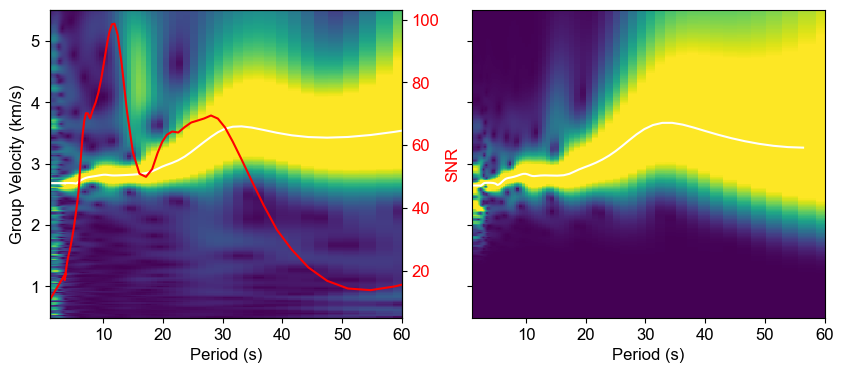

In [97]:
T_basic = basic_ftan_ds["target_period"].values
vel_basic = basic_ftan_ds["velocity"].values
norm_amp_basic = basic_ftan_ds["normalized_amplitude"].values
picked_instant_period_basic = basic_ftan_ds["picked_instant_period"].values
picked_group_vel_basic = basic_ftan_ds["picked_group_velocity"].values
picked_snr_basic = basic_ftan_ds["picked_snr"].values

T_pmf = pmf_ftan_ds["target_period"].values
vel_pmf = pmf_ftan_ds["velocity"].values
norm_amp_pmf = pmf_ftan_ds["normalized_amplitude"].values
picked_instant_period_pmf = pmf_ftan_ds["picked_instant_period"].values
picked_group_vel_pmf = pmf_ftan_ds["picked_group_velocity"].values
picked_snr_pmf = pmf_ftan_ds["picked_snr"].values


fig, ax = plt.subplots(1, 2, figsize=(10, 4), sharex=True, sharey=True)

ax[0].pcolormesh(T_basic, vel_basic, norm_amp_basic.T, shading="auto", cmap="viridis", vmin=0, vmax=0.75)
ax[0].plot(picked_instant_period_basic, picked_group_vel_basic, c='white')
ax[0].set_xlim([np.min(T_basic), np.max(T_basic)])
ax[0].set_xlabel('Period (s)')
ax[0].set_ylabel('Group Velocity (km/s)')

ax0_twinx = ax[0].twinx()
ax0_twinx.plot(picked_instant_period_basic, picked_snr_basic, c='red')
ax0_twinx.set_ylabel('SNR', color='red')
ax0_twinx.tick_params(axis='y', labelcolor='red')


ax[1].pcolormesh(T_pmf, vel_pmf, norm_amp_pmf.T, shading="auto", cmap="viridis", vmin=0, vmax=0.75)
ax[1].plot(picked_instant_period_pmf, picked_group_vel_pmf, c='white')
ax[1].set_xlabel('Period (s)')

# ax1_twinx = ax[1].twinx()
# ax1_twinx.plot(picked_instant_period_pmf, picked_snr_pmf, c='red')
# ax1_twinx.set_ylabel('SNR', color='red')
# ax1_twinx.tick_params(axis='y', labelcolor='red')

# ax[1].set_xlim([np.min(T_pmf), np.max(T_pmf)])

In [98]:
basic_vph_file = os.path.join(FTAN_seisforge_datadir, "COR_M07A_M15A.stack.phase_velocity.nc")
pmf_vph_file = os.path.join(FTAN_seisforge_datadir, "COR_M07A_M15A.stack.pmf_phase_velocity.nc")

basic_vph_ds = xr.open_dataset(basic_vph_file)
pmf_vph_ds = xr.open_dataset(pmf_vph_file)

print(basic_vph_ds)

<xarray.Dataset> Size: 161kB
Dimensions:                    (target_period: 81, phase_velocity: 240)
Coordinates:
  * target_period              (target_period) float64 648B 1.0 1.053 ... 60.0
  * phase_velocity             (phase_velocity) float64 2kB 0.5 0.5209 ... 5.5
Data variables:
    phase_candidate_amplitude  (target_period, phase_velocity) float64 156kB ...
    picked_phase_velocity      (target_period) float64 648B ...
    picked_group_velocity      (target_period) float64 648B ...
    picked_instant_period      (target_period) float64 648B ...
    picked_amplitude           (target_period) float64 648B ...
Attributes: (12/13)
    stage:                 basic
    branch:                stack
    input_file:            COR_M07A_M15A.SAC
    distance_km:           561.9387817382812
    alpha:                 14.992515222447249
    alpha_mode:            aftan_distance_scaling
    ...                    ...
    velocity_max:          5.5
    period_min:            1.0
    period

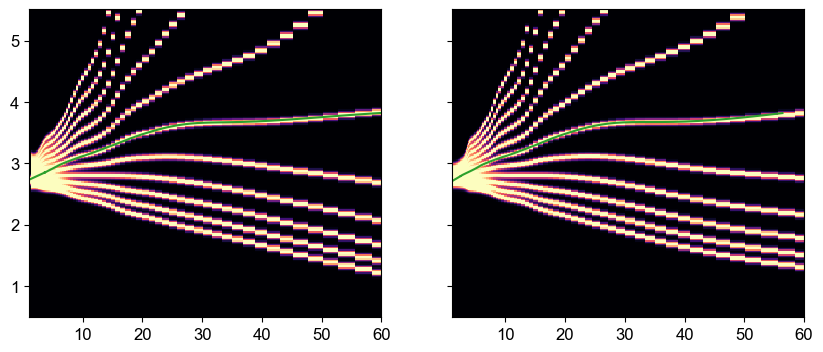

In [99]:
basic_T = basic_vph_ds["target_period"].values
basic_vel = basic_vph_ds["phase_velocity"].values
basic_phase_candidate_amplitude = basic_vph_ds["phase_candidate_amplitude"].values
basic_picked_phase_velocity = basic_vph_ds["picked_phase_velocity"].values
basic_picked_instant_period = basic_vph_ds["picked_instant_period"].values

fig, ax = plt.subplots(1, 2, figsize=(10, 4), sharex=True, sharey=True)
ax[0].pcolormesh(basic_T, basic_vel, basic_phase_candidate_amplitude.T, shading="auto", cmap="magma", vmin=0, vmax=0.75)
ax[0].plot(basic_picked_instant_period, basic_picked_phase_velocity, c='tab:green')
ax[0].set_xlim([np.min(basic_T), np.max(basic_T)])

pmf_T = pmf_vph_ds["target_period"].values
pmf_vel = pmf_vph_ds["phase_velocity"].values
pmf_phase_candidate_amplitude = pmf_vph_ds["phase_candidate_amplitude"].values
pmf_picked_phase_velocity = pmf_vph_ds["picked_phase_velocity"].values
pmf_picked_instant_period = pmf_vph_ds["picked_instant_period"].values
ax[1].pcolormesh(pmf_T, pmf_vel, pmf_phase_candidate_amplitude.T, shading="auto", cmap="magma", vmin=0, vmax=0.75)
ax[1].plot(pmf_picked_instant_period, pmf_picked_phase_velocity, c='tab:green')
# ax[1].set_xlim([np.min(pmf_T), np.max(pmf_T)])